# Project - Is There a Lead–Lag Effect Between SPY and AAPL?

Do price movements in the S&P 500 (SPY) propagate to AAPL with a short delay, at the minute or second level? Could such effects also appear in trading volume rather than prices, or even take the form of a reverse lead–lag relationship where AAPL leads SPY?

To address these questions, we analyze price variations, the correlation between volume and return spreads, and the relationship between volume and prices. The analysis is conducted using rolling windows at different time scales, with and without time lags, in order to identify potential high-frequency lead–lag effects.

*Names of all group members:*

•⁠  ⁠Raphaël Eliakim (raphael.eliakim@epfl.ch)

•⁠  ⁠David Mourier (david.mourier@epfl.ch)

•⁠  Arthur Dhonneur (arthur.dhonneur@epfl.ch)



## Importation of the packages


In [64]:
import polars as pl
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

## Data Preparation

In [65]:
pl.Config.set_tbl_cols(200)               
pl.Config.set_tbl_rows(50)                

polars.config.Config

In [66]:
df_merged_min_trade = pl.read_parquet("../data/clean/merged/merged_1min.parquet")
df_merged_min_trade_normalized = df_merged_min_trade.select(["datetime", "price_AAPL_normalized", "volume_AAPL_normalized", "return_AAPL_normalized", "price_SPY_normalized", "volume_SPY_normalized", "return_SPY_normalized"])

In [67]:
print(df_merged_min_trade_normalized.head())

shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ datetime     ┆ price_AAPL_ ┆ volume_AAPL ┆ return_AAPL ┆ price_SPY_n ┆ volume_SPY_ ┆ return_SPY_ │
│ ---          ┆ normalized  ┆ _normalized ┆ _normalized ┆ ormalized   ┆ normalized  ┆ normalized  │
│ datetime[μs, ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ UTC]         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2009-01-02   ┆ -1.530956   ┆ 2.783336    ┆ 1.3853      ┆ -0.379941   ┆ 4.939116    ┆ 2.532679    │
│ 14:30:00 UTC ┆             ┆             ┆             ┆             ┆             ┆             │
│ 2009-01-02   ┆ -1.534814   ┆ 0.2314      ┆ -3.012997   ┆ -0.37787    ┆ 1.941105    ┆ -2.137167   │
│ 14:31:00 UTC ┆             ┆             ┆             ┆             ┆     

## Plot Functions


In [68]:
colors_list = ["blue", "red", "green", "orange", "purple", "brown", "pink", "olive", "cyan"]

def plot_metric(df, metric, title = None, day_plot = False, mean_std_lines = False, colors = None):
    metric = metric.lower()
    metric_cols = [c for c in df.columns if metric in c.lower()]
    if len(metric_cols) == 0:
        print(f"No columns found for metric '{metric}'")
        return

    if colors is None:
        colors = colors_list[:len(metric_cols)]
    elif isinstance(colors, str):
        if len(metric_cols) > 1 :
            colors = colors_list[:len(metric_cols)]
        else :
            colors = [colors]
    elif len(colors) < len(metric_cols):
        colors = colors_list[:len(metric_cols)]

    if title is None and not day_plot:
        title = f"{metric.capitalize()} compared over the whole period"
    elif title is None:
        title = f"{metric.capitalize()} compared"
    plt.figure(figsize=(14,4))
    for col in metric_cols:
        col_label = col.replace("_", " ").replace("normalized", "").replace(metric, "").strip().capitalize()
        plt.plot(df["datetime"], df[col], label=col_label, color=colors[metric_cols.index(col)])
    if mean_std_lines and len(metric_cols) == 1:
        data = df[metric_cols[0]].to_numpy()
        mean = np.nanmean(data)
        std = np.nanstd(data)
        plt.axhline(mean, color='black', label='Mean')
        plt.axhline(mean + std, color='black', linestyle='--', label='Mean + 1 Std Dev')
        plt.axhline(mean - std, color='black', linestyle='--', label='Mean - 1 Std Dev')
    plt.title(title)
    plt.ylabel(f"{metric.replace("_", " ").replace("normalized", "").strip().capitalize()} (normalized)")
    plt.legend()
    if day_plot:
        plt.xlabel("Time")
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    else :
        plt.xlabel("Date")
    plt.xticks(rotation=40)
    plt.grid(True, alpha=0.2)
    plt.show()
    return

In [69]:
def plot_metric_day(df, metric, day):
    df_day = df.filter(pl.col("datetime").dt.date() == day)
    title = f"{metric.capitalize()} compared on {day}"
    plot_metric(df_day, metric, title, True)
    return

## Data Visualisation

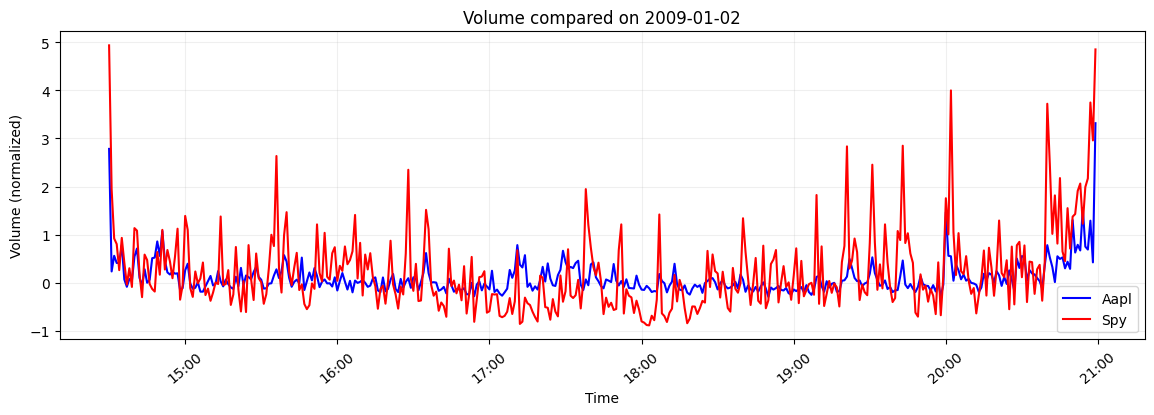

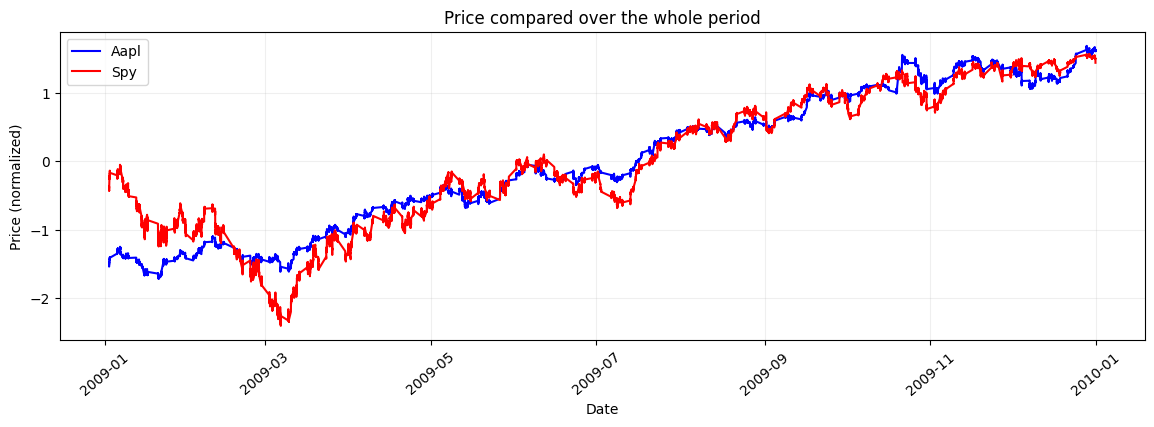

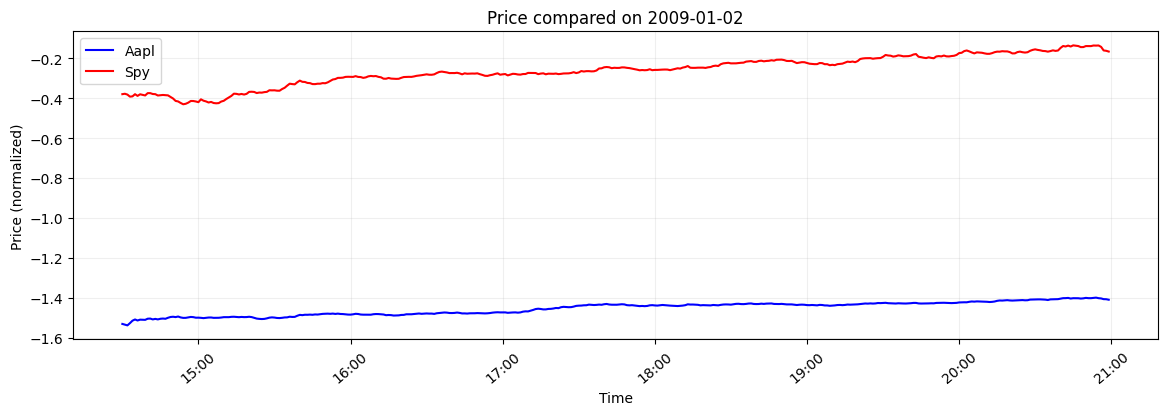

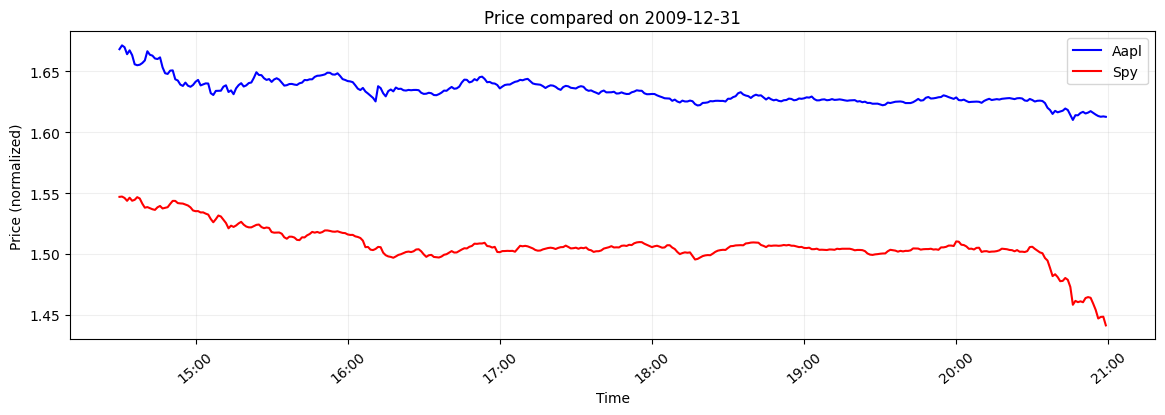

In [70]:
first_day = df_merged_min_trade_normalized["datetime"][0].date()
last_day = df_merged_min_trade_normalized["datetime"][-1].date()

plot_metric_day(df_merged_min_trade_normalized, "volume", first_day)
plot_metric(df_merged_min_trade_normalized, "price")
plot_metric_day(df_merged_min_trade_normalized, "price", first_day)
plot_metric_day(df_merged_min_trade_normalized, "price", last_day)

## Return Visualisation


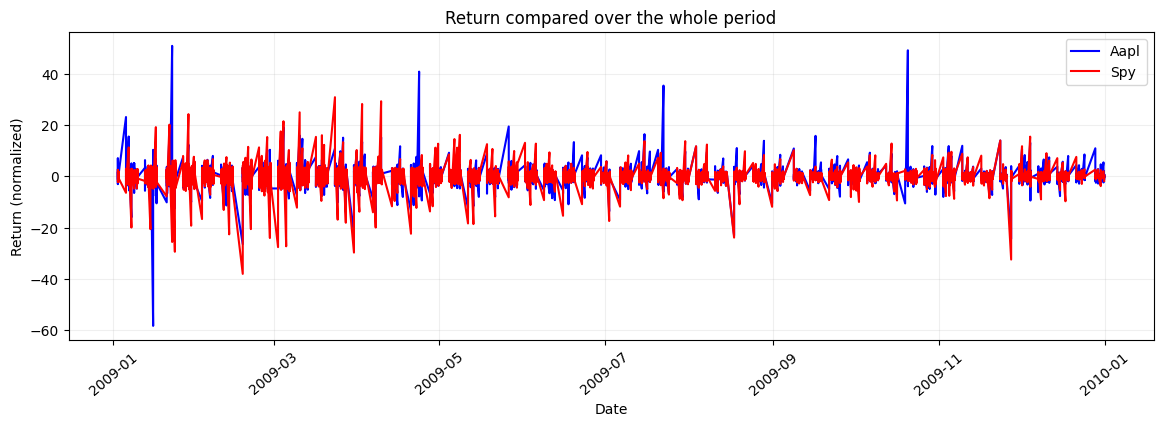

In [71]:
plot_metric(df_merged_min_trade_normalized, "return")

## Comparaison between Gaussian law and our Returns

In [72]:
def plot_gaussian_fit(df, metric = None, label = None, nb_bins = 50, coeff = 1.1):
    df = df.to_numpy()
    mu, sigma = np.mean(df), np.std(df)
    color = colors_list[:2]
    plt.figure(figsize=(6,4))
    plt.hist(df, bins=nb_bins, density=True, color=color[0], label="Empirical")
    x_axis = np.linspace(df.min()/coeff, df.max()*coeff, 200)
    plt.plot(x_axis, norm.pdf(x_axis, mu, sigma), color=color[1], label="Gaussian fit")
    if metric is not None and label is not None:
        plt.title(f"Distribution of {label} normalized {metric}s with Gaussian fit")
        plt.xlabel(metric)
    elif label is not None:
        plt.title(f"Distribution of {label} with Gaussian fit")
        plt.xlabel("Value")
    elif metric is not None:
        plt.title(f"Distribution of normalized {metric} with Gaussian fit")
        plt.xlabel(metric)
    else:
        plt.title("Distribution with Gaussian fit")
        plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()
    return

In [73]:
def plot_qq(df, metric=None, label=None):
    plt.figure(figsize=(6,4))
    stats.probplot(df.to_numpy(), dist="norm", plot=plt)
    if metric is not None and label is not None:
        plt.gca().set_title(f"QQ-Plots of {label} normalized {metric} vs Normal Distribution")
    elif label is not None:
        plt.gca().set_title(f"QQ-Plots of {label} vs Normal Distribution")
    elif metric is not None:
        plt.gca().set_title(f"QQ-Plots of normalized {metric} vs Normal Distribution")
    else:
        plt.gca().set_title("QQ-Plots vs Normal Distribution")
    plt.grid(alpha=0.2)
    plt.show()
    return

In [74]:
def plot_ACF(df, lags=10, metric=None, label=None):
    df = df.to_numpy()
    plt.figure(figsize=(6,4))
    plot_acf(df, lags=lags, color=colors_list[0])
    if metric is not None and label is not None:
        plt.title(f"Autocorrelation Function (ACF) of {label} normalized {metric}")
    elif label is not None:
        plt.title(f"Autocorrelation Function (ACF) of {label}")
    elif metric is not None:
        plt.title(f"Autocorrelation Function (ACF) of normalized {metric}")
    else:
        plt.title("Autocorrelation Function (ACF)")
    plt.xlabel("Lags")
    plt.ylabel("ACF")
    plt.grid(alpha=0.2)
    plt.show()
    return

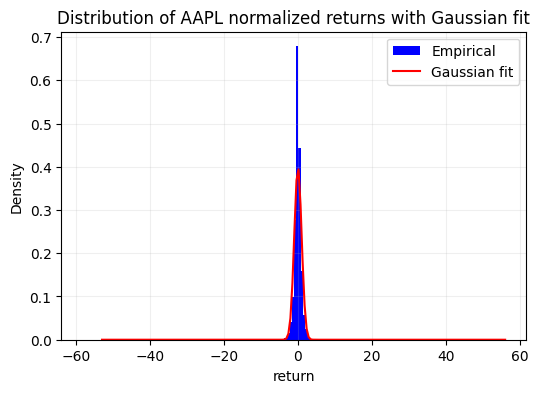

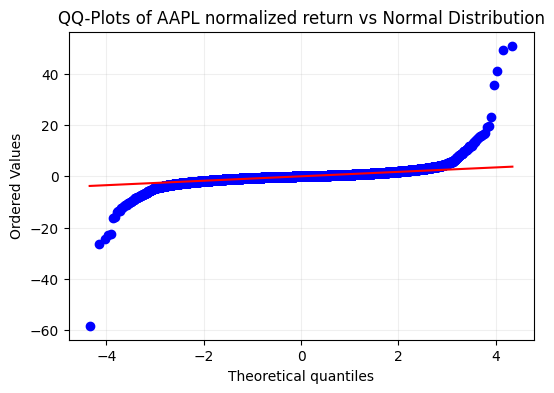

<Figure size 600x400 with 0 Axes>

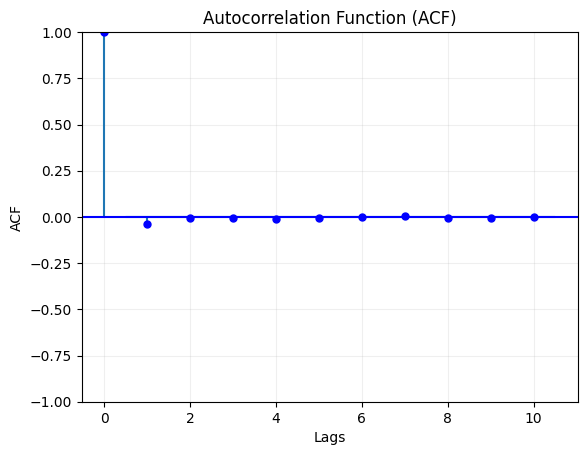

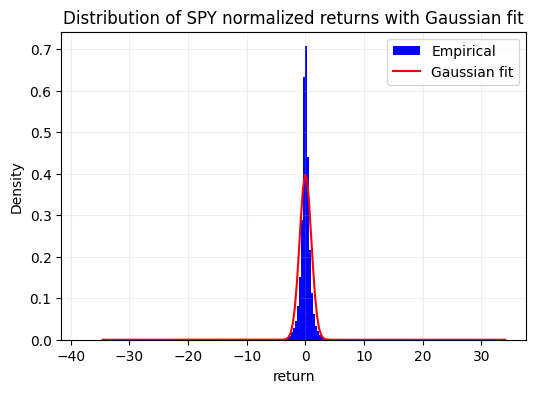

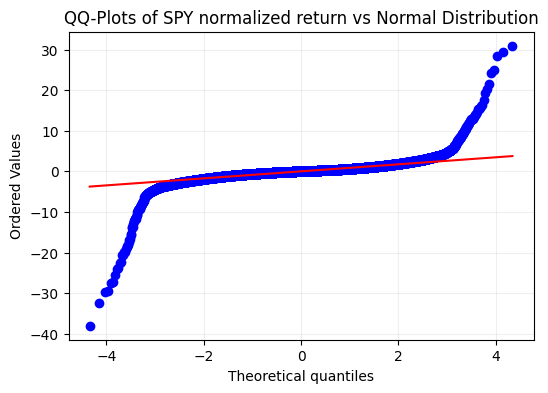

<Figure size 600x400 with 0 Axes>

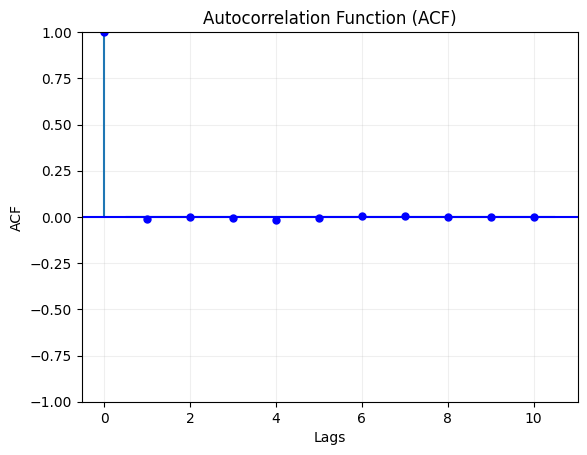

In [75]:
for col in ["return_AAPL_normalized", "return_SPY_normalized"]:
    label = col.replace("_", " ").replace("normalized", "").replace("return", "").strip().upper()
    metric = "return"
    df_col = df_merged_min_trade_normalized[col]
    plot_gaussian_fit(df_col, metric, label, 200)
    plot_qq(df_col, metric, label)
    plot_ACF(df_col)

## Observation

The empirical return distribution is more sharply peaked around zero and exhibits much heavier tails than the Gaussian fit, indicating excess kurtosis.  
This is confirmed by the QQ-plot, where extreme returns deviate strongly from the straight line, showing that the Gaussian law underestimates tail risk.

## Cross Corellation (with and witout lag)

In [76]:
def cross_corr_at_lag(df_1, df_2, lag):
    """
    Compute correlation between df_1(t+lag) and df_2(t)
    lag > 0  -> test if df_2 leads df_1
    lag < 0  -> test if df_1 leads df_2
    """
    df_1 = df_1.to_numpy()
    df_2 = df_2.to_numpy()
    if lag > 0:
        return np.corrcoef(df_1[lag:], df_2[:-lag])[0, 1]
    elif lag < 0:
        lag = -lag
        return np.corrcoef(df_1[:-lag], df_2[lag:])[0, 1]
    else:
        return np.corrcoef(df_1, df_2)[0, 1]


In [77]:
def plot_cross_corr(df_1, df_2, lags, metric_1 = None, metric_2 = None, label_1="", label_2="", sec = False):
    cc_values = [cross_corr_at_lag(df_1, df_2, lag) for lag in lags]
    plt.figure(figsize=(10,4))
    plt.stem(lags, cc_values, basefmt=" ", linefmt="b-", markerfmt="bo")
    plt.axhline(0, color='blue')
    if metric_1 is None or metric_2 is None:
        plt.title(f"Cross-Correlation between {label_1} and {label_2} at different lags")
    else:
        plt.title(f"Cross-Correlation between {label_1} normalized {metric_1} and {label_2} normalized {metric_2} at different lags")
    if sec:
        plt.xlabel("Lags (seconds)")
    else:
        plt.xlabel("Lags (minutes)")
    plt.ylabel("Cross-Correlation")
    plt.grid(alpha=0.2)
    plt.show()
    return cc_values

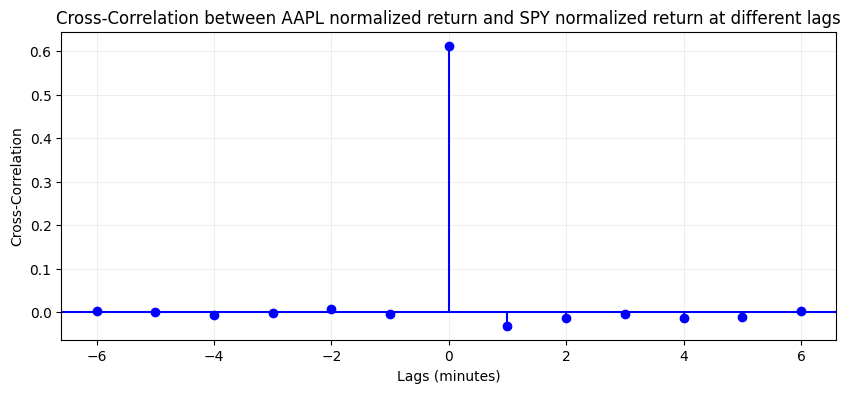

In [78]:
lags_min = range(-6, 7)  # -6 to +6
_ = plot_cross_corr(df_merged_min_trade_normalized["return_AAPL_normalized"], df_merged_min_trade_normalized["return_SPY_normalized"], lags_min, "return", "return", "AAPL", "SPY")

## Observation

No clear lead–lag relationship is observed at the minute scale, as cross-correlations are close to zero for all non-zero lags.  
This result is expected since both assets are highly traded and any arbitrage effects occur at much higher frequencies (microseconds rather than minutes), making a near-zero cross-correlation at this scale reasonable; therefore, we turn to second-level data for finer analysis.

In [79]:
df_merged_sec_trade = pl.read_parquet("../data/clean/merged/merged_1sec.parquet")
df_merged_sec_trade_normalized = df_merged_sec_trade.select(["datetime", "price_AAPL_normalized", "volume_AAPL_normalized", "return_AAPL_normalized", "price_SPY_normalized", "volume_SPY_normalized", "return_SPY_normalized"])
print(df_merged_sec_trade_normalized.head())

shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ datetime     ┆ price_AAPL_ ┆ volume_AAPL ┆ return_AAPL ┆ price_SPY_n ┆ volume_SPY_ ┆ return_SPY_ │
│ ---          ┆ normalized  ┆ _normalized ┆ _normalized ┆ ormalized   ┆ normalized  ┆ normalized  │
│ datetime[μs, ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ UTC]         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2009-01-02   ┆ -1.325655   ┆ 0.148969    ┆ -3.002701   ┆ -0.162332   ┆ -0.232075   ┆ -0.579949   │
│ 14:30:00 UTC ┆             ┆             ┆             ┆             ┆             ┆             │
│ 2009-01-02   ┆ -1.326754   ┆ -0.046839   ┆ -0.335281   ┆ -0.15765    ┆ 0.910346    ┆ -0.000455   │
│ 14:30:02 UTC ┆             ┆             ┆             ┆             ┆     

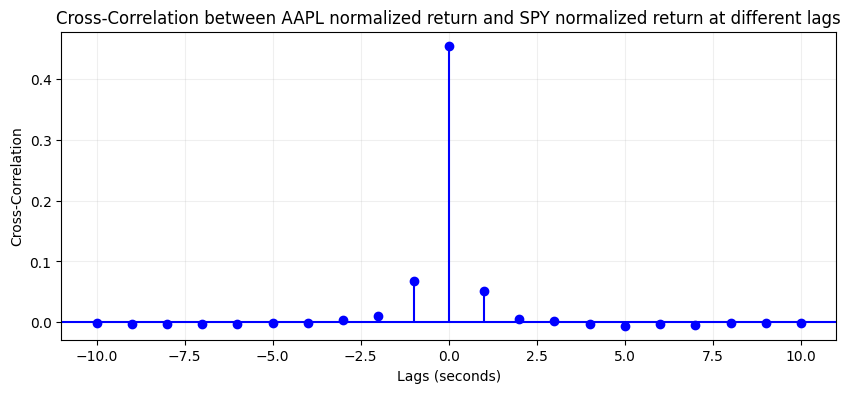

In [80]:
lags_sec = range(-10, 11)  # -10 to +10
_ = plot_cross_corr(df_merged_sec_trade_normalized["return_AAPL_normalized"], df_merged_sec_trade_normalized["return_SPY_normalized"], lags_sec, "return", "return", "AAPL", "SPY", True)

## Observation

At the second scale, we observe a noticeable cross-correlation at very short lags, indicating a relationship between the two assets.  
This suggests that interactions occur at extremely high frequencies; one would expect even stronger effects at the microsecond level, but such analysis is not possible here due to data limitations.

- This result is also expected since AAPL is a constituent of the S&P 500, so its returns are mechanically and economically linked to those of SPY, especially at very short horizons.

## Relation volume - Price


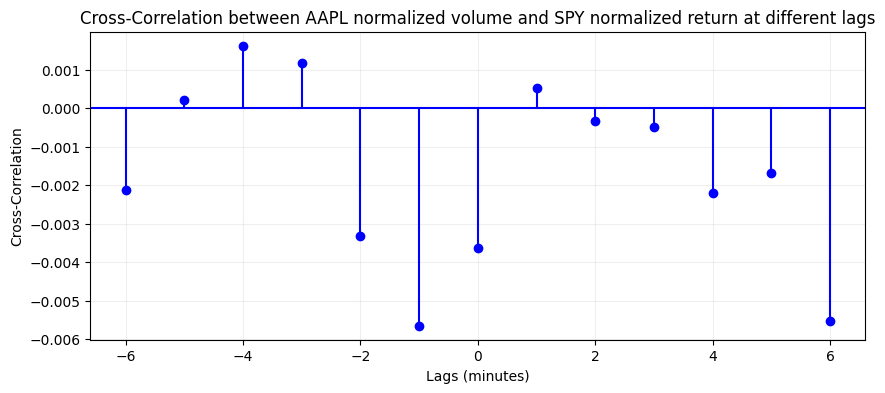

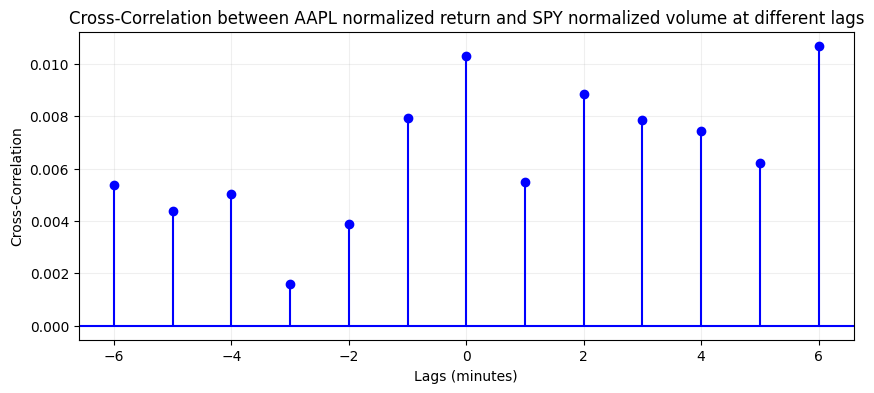

In [81]:
_ = plot_cross_corr(df_merged_min_trade_normalized["volume_AAPL_normalized"], df_merged_min_trade_normalized["return_SPY_normalized"], lags_min, "volume", "return", "AAPL", "SPY")
_ = plot_cross_corr(df_merged_min_trade_normalized["return_AAPL_normalized"], df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return", "volume", "AAPL", "SPY")

## Observation

These two plots show that the cross-correlation between trading volume and returns is overall weak, with no clear or stable structure across minute-level lags.  
Some isolated peaks and asymmetries appear, suggesting that trading activity may slightly react to or precede price movements, but these effects remain small and noisy, which is consistent with highly liquid and efficient markets.

Let's anaylise it in secondes now:

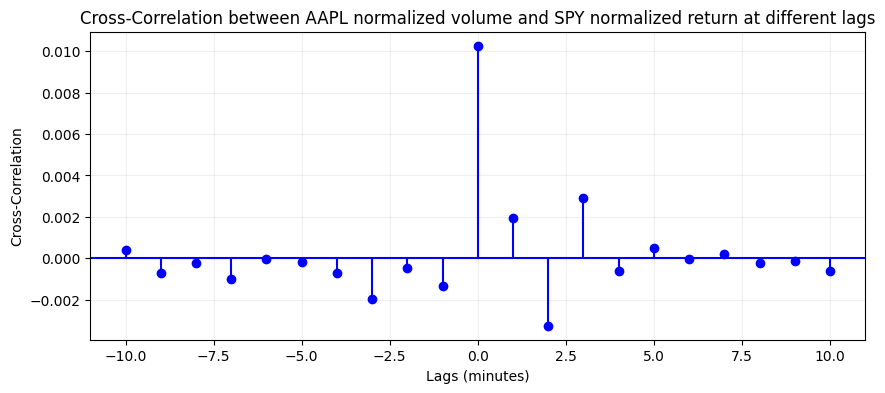

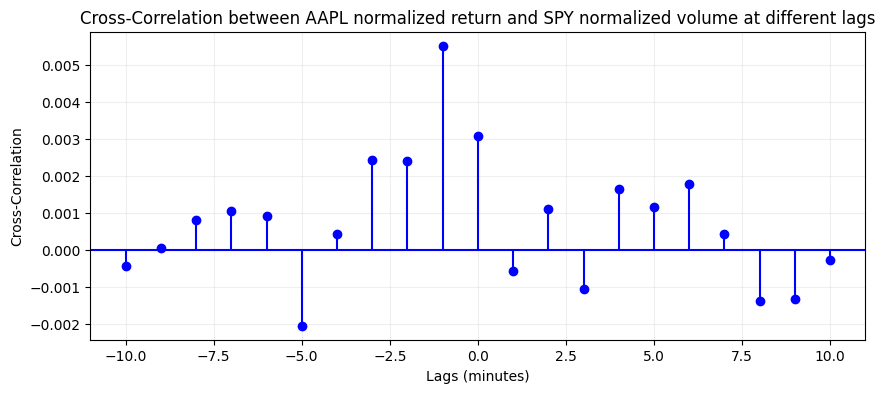

In [82]:
_ = plot_cross_corr(df_merged_sec_trade_normalized["volume_AAPL_normalized"], df_merged_sec_trade_normalized["return_SPY_normalized"], lags_sec, "volume", "return", "AAPL", "SPY")
_ = plot_cross_corr(df_merged_sec_trade_normalized["return_AAPL_normalized"], df_merged_sec_trade_normalized["volume_SPY_normalized"], lags_sec, "return", "volume", "AAPL", "SPY")

## Correaltion between Returns over multiple Rolling Windows

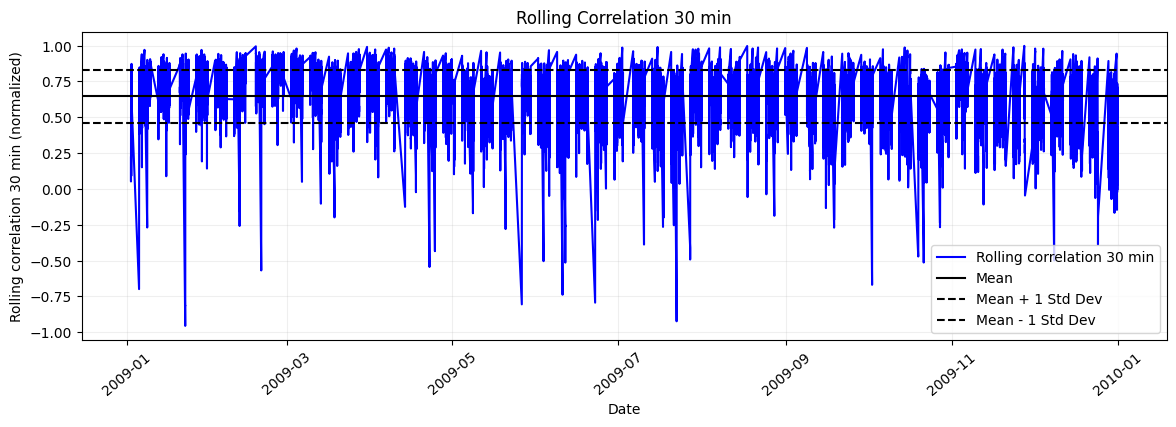

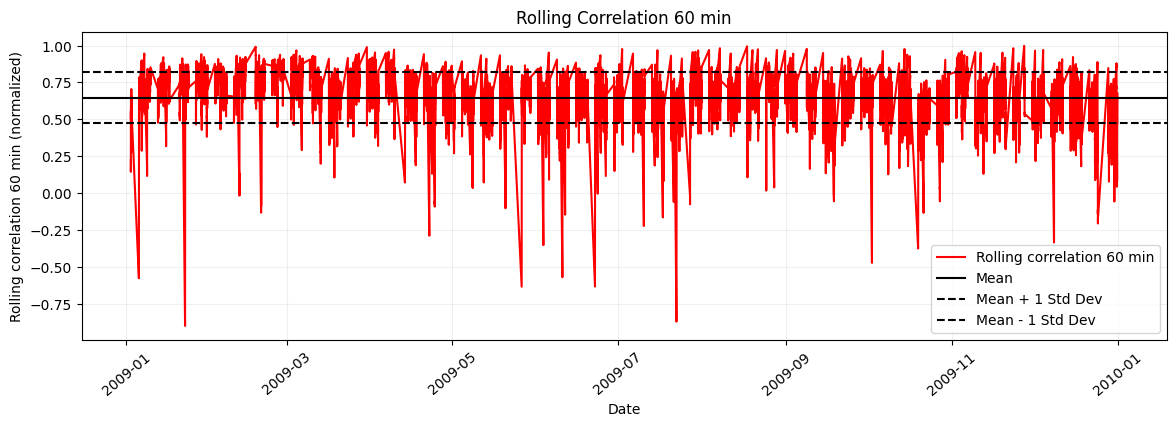

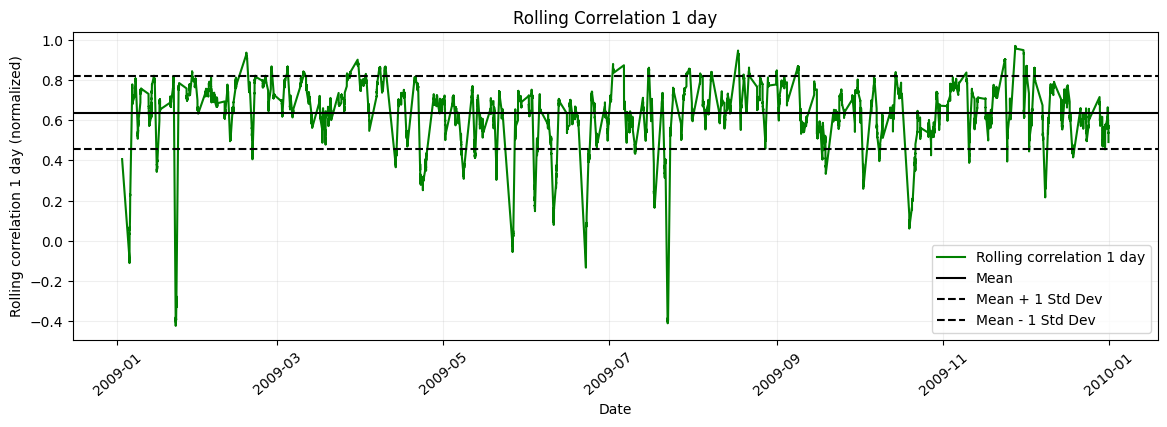

In [83]:
#Rolling correlations ret_AAPL, ret_SPY (30min, 60min, 1day)
df_roll = (
    df_merged_min_trade_normalized
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=30).alias("rolling_correlation_30_min"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("rolling_correlation_60_min"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=390).alias("rolling_correlation_1_day"),
    ])
)

#Rolling lead–lag correlation (lags −1, 0, +1 minute)
df_roll = (
    df_roll
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(-1),window_size=60).alias("lag_m1"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("lag_0"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(1),window_size=60).alias("lag_p1"),
    ])
)

plot_metric(df_roll, "rolling_correlation_30_min", title="Rolling Correlation 30 min", mean_std_lines=True, colors=colors_list[0])
plot_metric(df_roll, "rolling_correlation_60_min", title="Rolling Correlation 60 min", mean_std_lines=True, colors=colors_list[1])
plot_metric(df_roll, "rolling_correlation_1_day", title="Rolling Correlation 1 day", mean_std_lines=True, colors=colors_list[2])

## Observation

Across the three horizons, the rolling correlation remains clearly positive on average, with a mean around **0.75–0.8** for the 30-minute and 60-minute windows, and slightly lower (around **0.65–0.7**) at the daily level.  

At short horizons (30 and 60 minutes), the correlation is very volatile: although it stays most of the time above the mean, there are frequent sharp drops that can go as low as **−0.8**, which is likely due to intraday noise and market microstructure effects.  

At the 1-day horizon, the correlation is much smoother and fluctuates within a narrower range, mostly between **0.5 and 0.85**, indicating that while short-term dynamics are noisy, the long-term relationship between the two assets is more stable and economically meaningful.

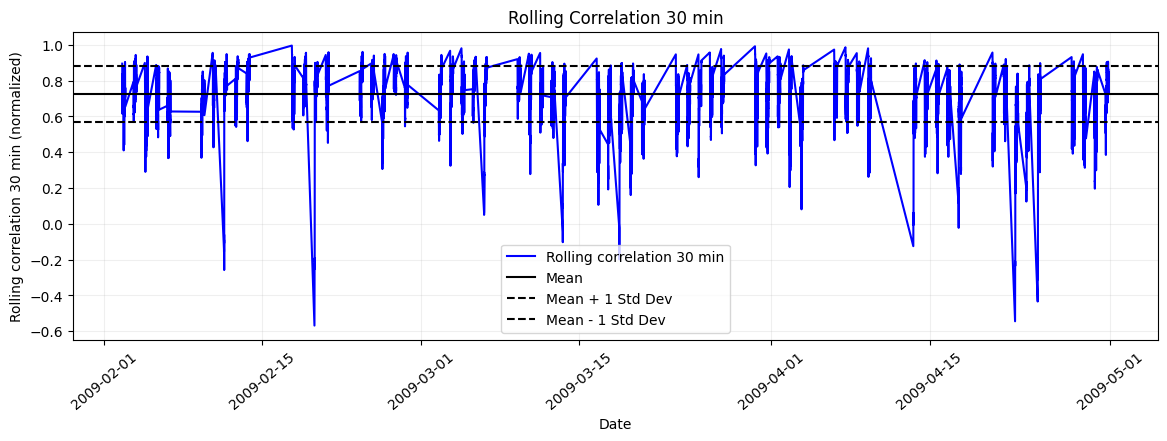

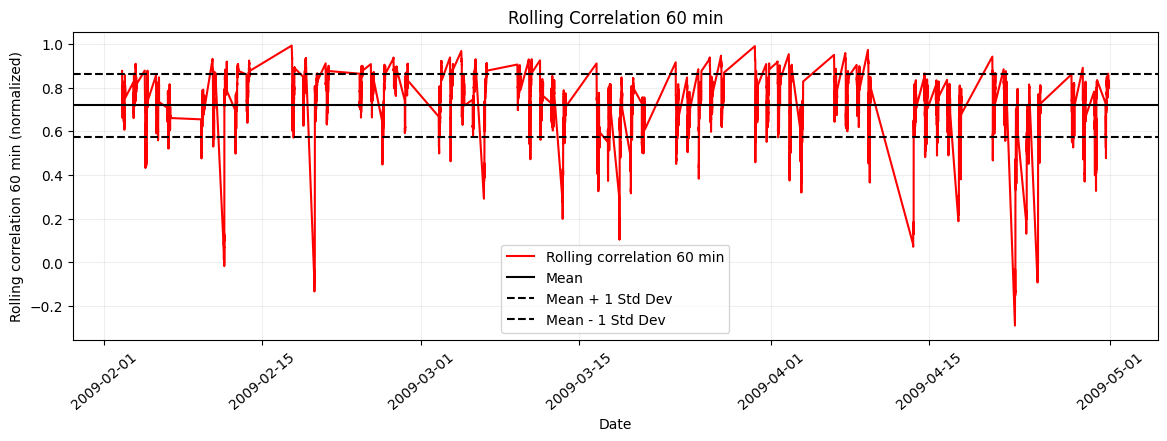

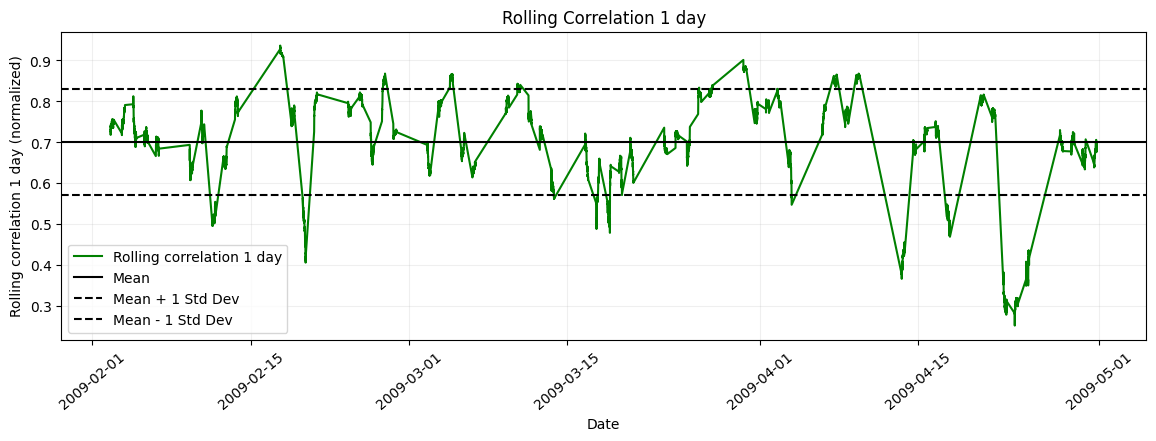

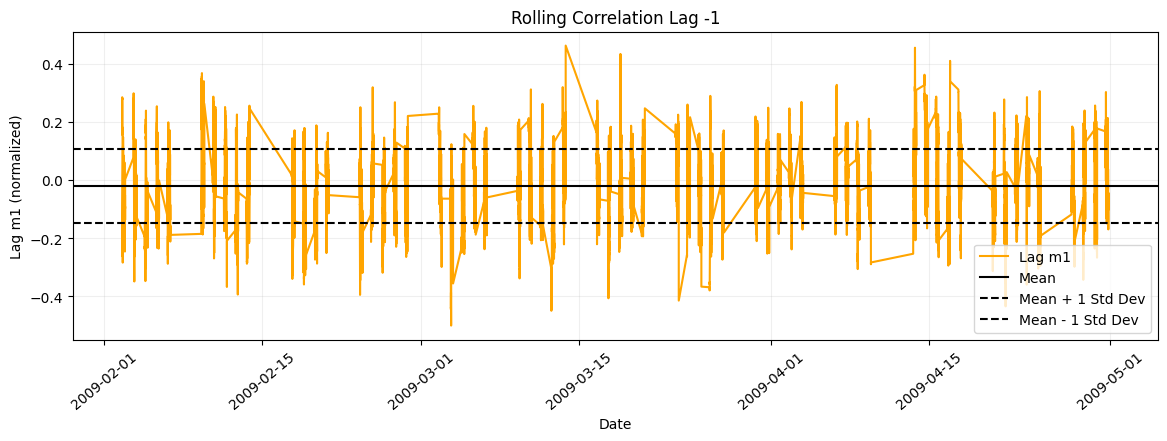

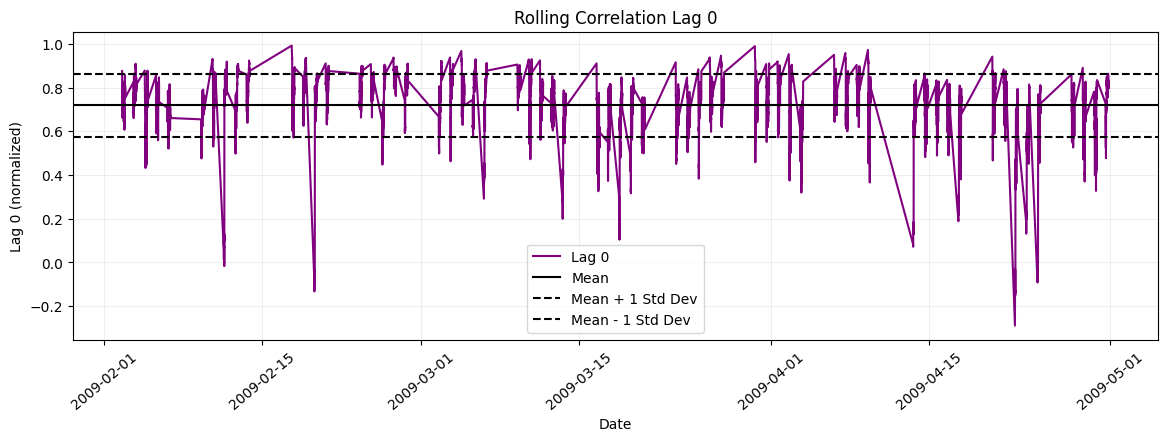

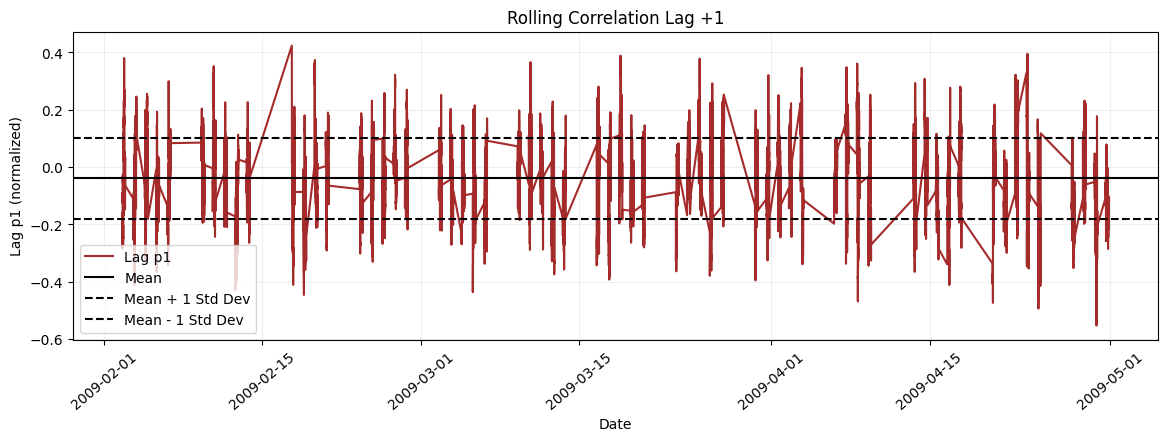

In [85]:
#On the sub-period, to be easier to see the fluctuations

df_sub = df_roll.filter(
    (pl.col("datetime") >= pl.datetime(2009, 2, 1, time_zone="UTC")) &
    (pl.col("datetime") <  pl.datetime(2009, 5, 1, time_zone="UTC"))
)

plot_metric(df_sub, "rolling_correlation_30_min", title="Rolling Correlation 30 min", mean_std_lines=True, colors=colors_list[0])
plot_metric(df_sub, "rolling_correlation_60_min", title="Rolling Correlation 60 min", mean_std_lines=True, colors=colors_list[1])
plot_metric(df_sub, "rolling_correlation_1_day", title="Rolling Correlation 1 day", mean_std_lines=True, colors=colors_list[2])

plot_metric(df_sub, "lag_m1", title="Rolling Correlation Lag -1", mean_std_lines=True, colors=colors_list[3])
plot_metric(df_sub, "lag_0", title="Rolling Correlation Lag 0", mean_std_lines=True, colors=colors_list[4])
plot_metric(df_sub, "lag_p1", title="Rolling Correlation Lag +1", mean_std_lines=True, colors=colors_list[5])


## Observation

These three last plots highlight a clear difference with lagged correlations.  
At **lag 0**, the rolling correlation is strongly positive, with a mean around **0.75–0.8**, confirming that both assets move together at the same time. Although there are occasional sharp drops, the correlation remains most of the time well above the mean, indicating a robust relationship.

At **lag −1** and **lag +1**, the average correlation is much closer to **0**, fluctuating roughly between **−0.2 and 0.2**, with no persistent structure over time. This suggests that past returns of one asset do not significantly predict future returns of the other at the minute scale.

Overall, these results are consistent with an efficient market where information is incorporated almost instantaneously. Based on this, we now turn to second-level data to check whether correlations increase at higher frequencies, as we would expect if lead–lag effects occur at very short time scales.

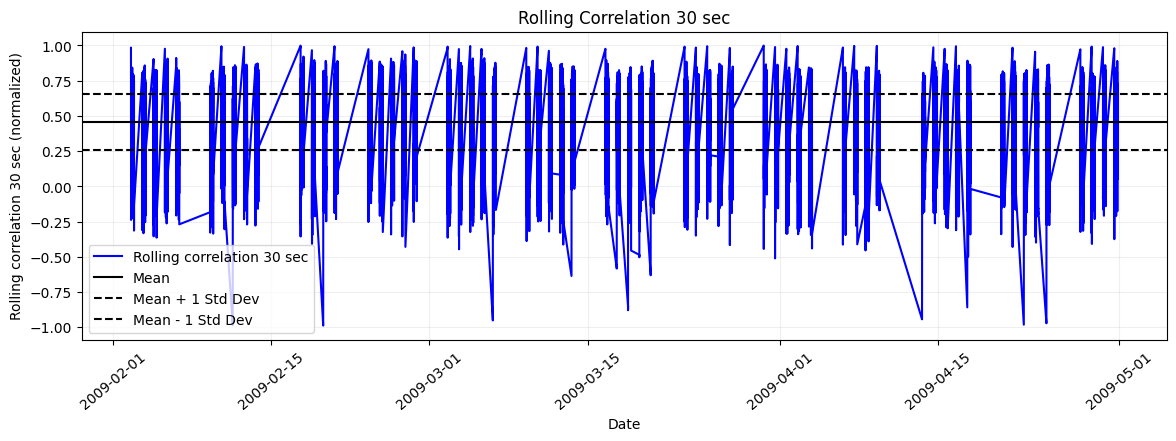

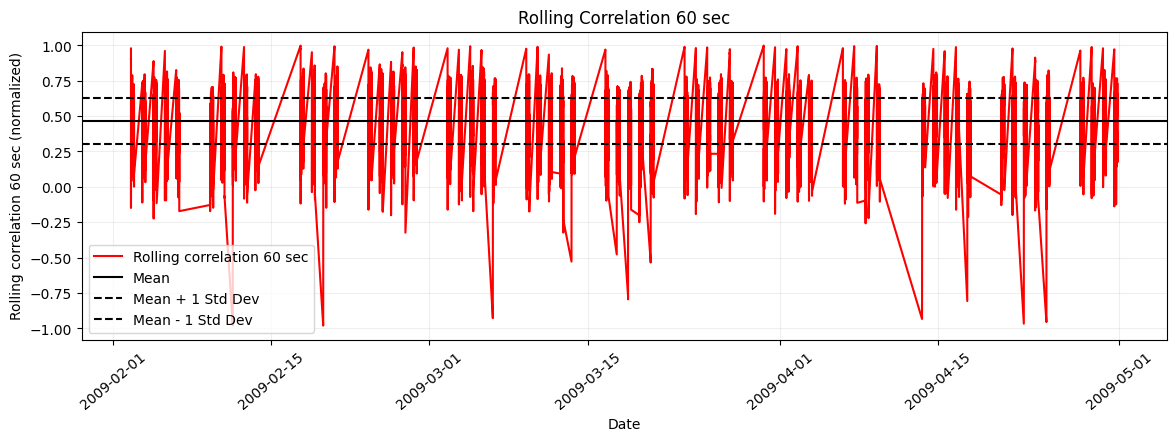

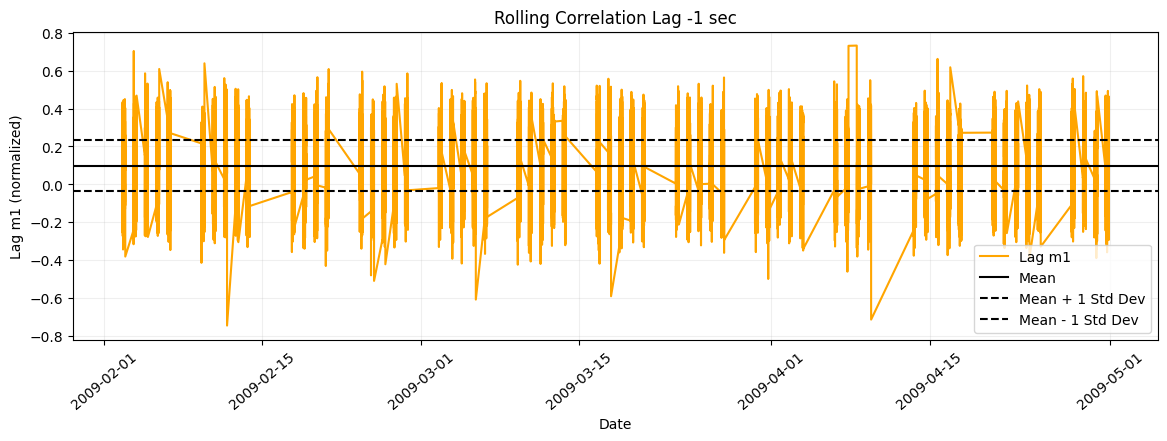

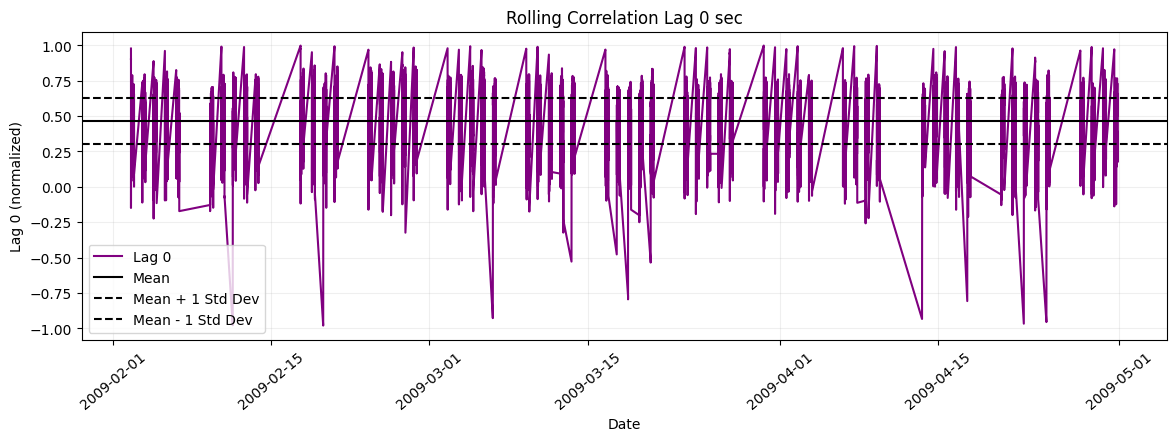

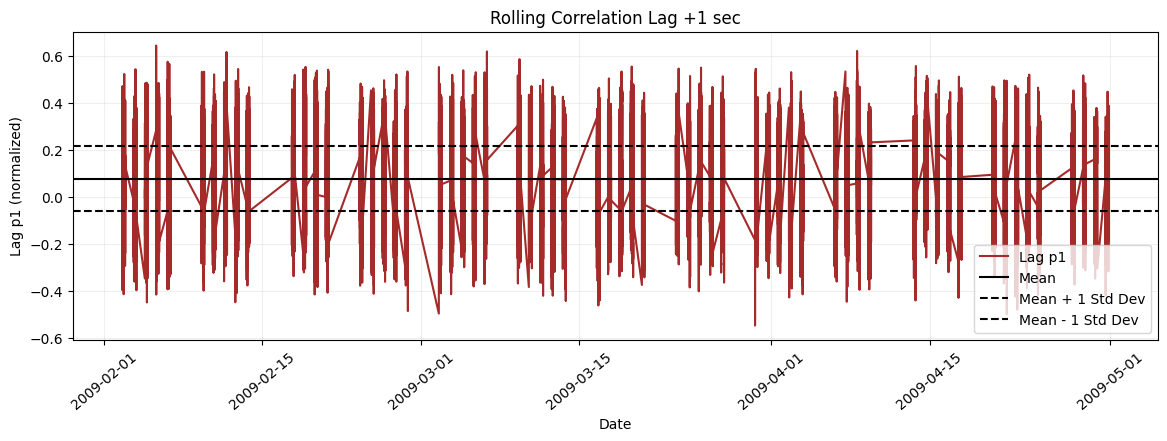

In [87]:
# Same analysis on second-level data
df_roll_sec = (
    df_merged_sec_trade_normalized
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=30).alias("rolling_correlation_30_sec"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("rolling_correlation_60_sec"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=23400).alias("rolling_correlation_1_day"),
    ])
)

#Rolling lead–lag correlation (lags −1, 0, +1 second)
df_roll_sec = (
    df_roll_sec
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(-1),window_size=60).alias("lag_m1"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("lag_0"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(1),window_size=60).alias("lag_p1"),
    ])
)

df_sub_sec = df_roll_sec.filter(
    (pl.col("datetime") >= pl.datetime(2009, 2, 1, time_zone="UTC")) &
    (pl.col("datetime") <  pl.datetime(2009, 5, 1, time_zone="UTC"))
)

plot_metric(df_sub_sec, "rolling_correlation_30_sec", title="Rolling Correlation 30 sec", mean_std_lines=True, colors=colors_list[0])
plot_metric(df_sub_sec, "rolling_correlation_60_sec", title="Rolling Correlation 60 sec", mean_std_lines=True, colors=colors_list[1])

plot_metric(df_sub_sec, "lag_m1", title="Rolling Correlation Lag -1 sec", mean_std_lines=True, colors=colors_list[3])
plot_metric(df_sub_sec, "lag_0", title="Rolling Correlation Lag 0 sec", mean_std_lines=True, colors=colors_list[4])
plot_metric(df_sub_sec, "lag_p1", title="Rolling Correlation Lag +1 sec", mean_std_lines=True, colors=colors_list[5])

## Observation

At the **30-second** and **60-second** rolling windows, the correlation remains clearly positive, with an average level around **0.6–0.7**, but with very strong short-term fluctuations and occasional sharp negative spikes.

When introducing **lags in seconds**, differences emerges compared to the minute-level analysis. At **lag 0 seconds**, the correlation remains strong and stable, while at **lag −1 second** and **lag +1 second**, the average correlation is no longer close to zero but instead fluctuates around **0.1**. Although this value is small, it is persistent over time and consistently above zero, suggesting a meaningful lead–lag relationship at this time scale.

Overall, these results indicate that information transmission between the two assets does not occur at the minute level but becomes detectable at the second level. This is consistent with highly liquid markets, where reactions are extremely fast. It is therefore reasonable to expect that this effect could be even more pronounced at the **microsecond level**, where most high-frequency arbitrage activity actually takes place, although such dynamics cannot be observed here due to data limitations.

## Data Analysis of the cross correlation between spread returns and volume 

In [88]:
df_merged_min_trade_normalized = df_merged_min_trade_normalized.with_columns(
    (pl.col("return_AAPL_normalized") - pl.col("return_SPY_normalized")).alias("diff_normalized_return")
)

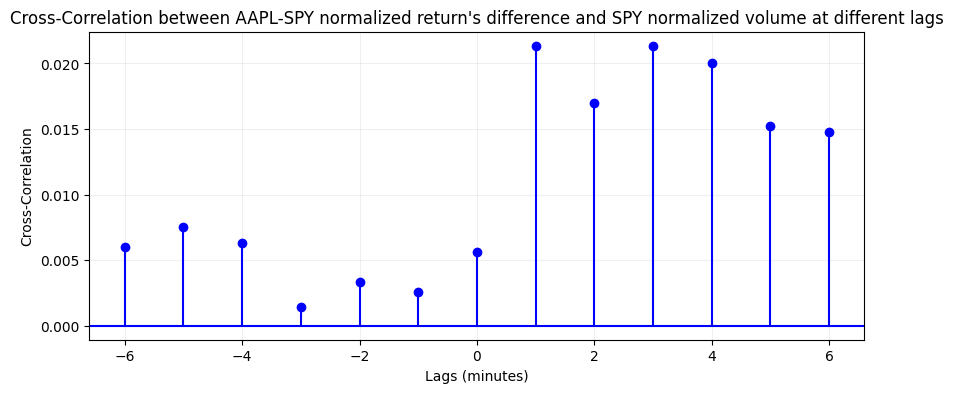

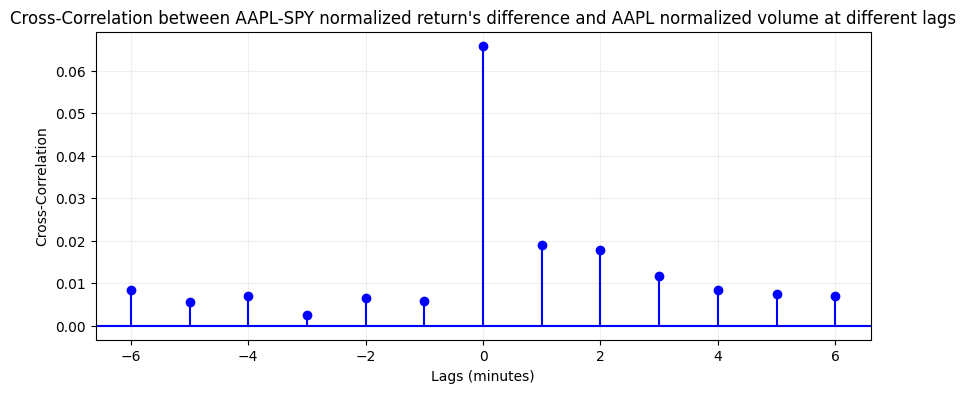

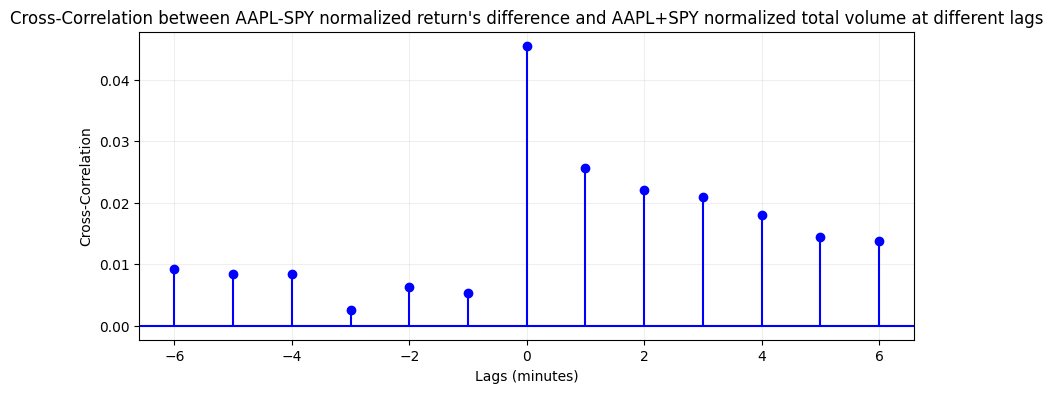

In [89]:
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return's difference", "volume", "AAPL-SPY", "SPY")
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_AAPL_normalized"], lags_min, "return's difference", "volume", "AAPL-SPY", "AAPL")
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_AAPL_normalized"] + df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return's difference", "total volume", "AAPL-SPY", "AAPL+SPY")

## Observation

These three cross-correlation plots compare the AAPL–SPY return spread with different measures of trading volume, and they all point to a consistent pattern.

First, when looking at **SPY volume**, the correlation is positive and peaks at short positive lags, with values around **0.02**. This suggests that increases in market-wide trading activity tend to be followed by movements in the AAPL–SPY return difference, which is intuitive since SPY volume reflects overall market pressure.

Second, using **AAPL volume**, the contemporaneous correlation at **lag 0** is clearly stronger, reaching values close to **0.06**. This indicates that AAPL-specific trading activity is more directly linked to relative price movements between AAPL and SPY, especially at very short horizons.

Finally, when considering the **total volume (AAPL + SPY)**, the correlation remains positive and significant, with a peak around **0.04–0.05** at lag 0 and slightly positive values at nearby lags. This reinforces the idea that overall trading intensity amplifies short-term relative price dynamics.


## Same but in secondes 

In [90]:
df_merged_sec_trade_normalized = df_merged_sec_trade_normalized.with_columns(
    (pl.col("return_AAPL_normalized") - pl.col("return_SPY_normalized")).alias("diff_normalized_return")
)

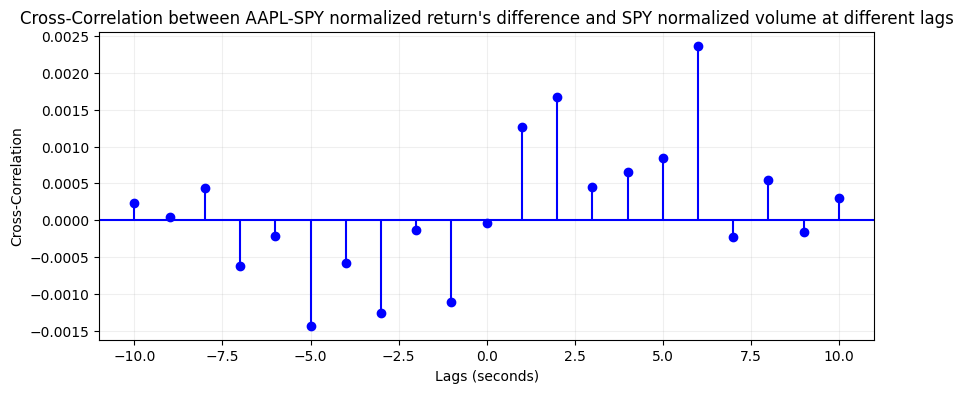

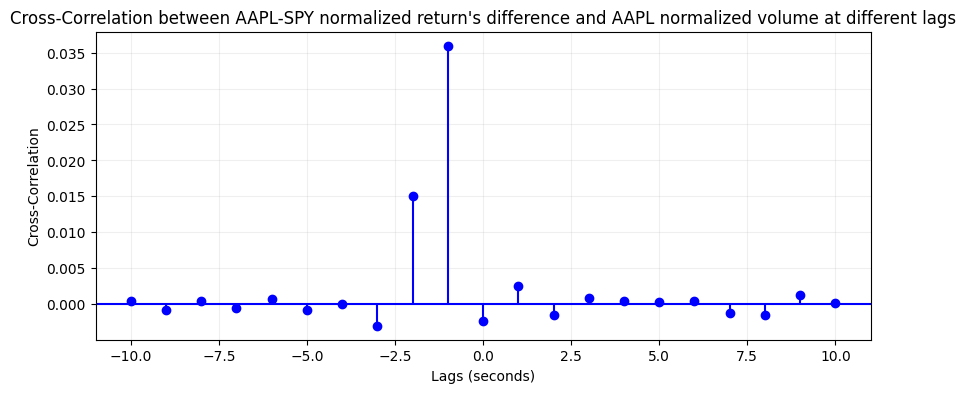

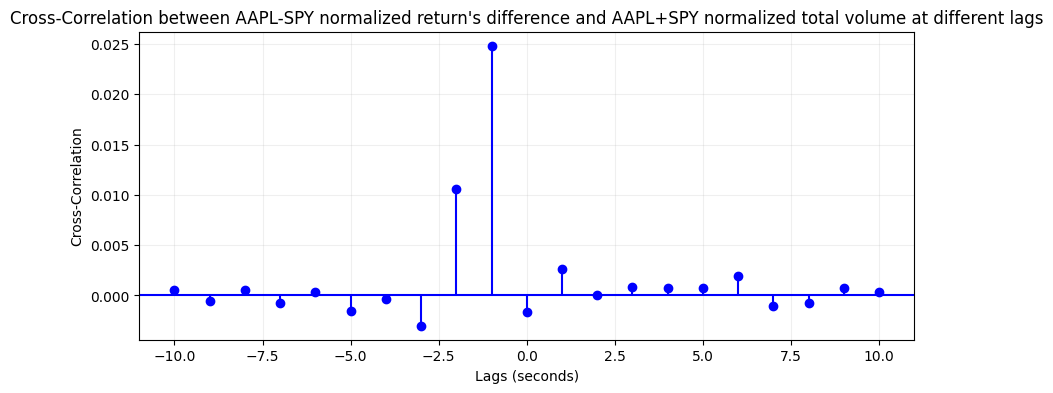

In [91]:
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_SPY_normalized"], lags_sec, "return's difference", "volume", "AAPL-SPY", "SPY", True)
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_AAPL_normalized"], lags_sec, "return's difference", "volume", "AAPL-SPY", "AAPL", True)
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_AAPL_normalized"] + df_merged_sec_trade_normalized["volume_SPY_normalized"], lags_sec, "return's difference", "total volume", "AAPL-SPY", "AAPL+SPY", True)

## Observation

At the **second level**, the cross-correlations between the AAPL–SPY return spread and volumes remain **very small overall**, and the lead–lag structure is weaker than what we observed at the minute scale.

For **SPY volume**, correlations stay close to zero, with only small positive spikes (around **0.002–0.0025**) at a few positive lags, which is likely too small to claim a strong predictive effect.  

For **AAPL volume**, there is still a clearer signal than for SPY, with a peak around **0.03–0.035** at very short lags, but it remains localized and does not persist across many lags.  

For the **total volume (AAPL + SPY)**, the correlation is intermediate and still modest (around **0.02–0.025** at its peak), suggesting some link between overall trading intensity and short-term relative returns, but the effect is not large.

Overall, these second-level plots suggest that any volume-driven lead–lag effect is weak and highly concentrated at very short horizons. If such a mechanism exists, it would most likely be stronger at even higher frequencies 

## Compute rolling correlation between AAPL-SPY return spread and volume, conditional on high-volume days.

In [92]:
def conditional_rolling_correlation(df,volume_type="total",top_quantile=0.80,window=60,lag=0):
    """
    Compute rolling correlation between AAPL-SPY return spread and volume,
    conditional on high-volume days.
    """
    df_pd = df.to_pandas()
    
    if "date" not in df_pd.columns:
        df_pd["date"] = df_pd["datetime"].dt.date
    
    # Define volume used for conditioning and correlation
    if volume_type == "AAPL":
        volume_col = "volume_AAPL_normalized"
        df_pd["conditioning_volume"] = df_pd[volume_col]
    elif volume_type == "SPY":
        volume_col = "volume_SPY_normalized"
        df_pd["conditioning_volume"] = df_pd[volume_col]
    elif volume_type == "total":
        # Créer la colonne de volume total
        df_pd["conditioning_volume"] = (
            df_pd["volume_AAPL_normalized"] +
            df_pd["volume_SPY_normalized"]
        )
        volume_col = "conditioning_volume"
    else:
        raise ValueError("volume_type must be 'AAPL', 'SPY', or 'total'")
    
    # Compute daily total volume
    daily_volume = (
        df_pd.groupby("date")["conditioning_volume"]
        .sum()
        .reset_index(name="daily_volume")
    )
    
    # Select top X% volume days (top 20% si top_quantile=0.80)
    threshold = daily_volume["daily_volume"].quantile(top_quantile)
    high_volume_days = daily_volume.loc[
        daily_volume["daily_volume"] >= threshold, "date"
    ]
    
    print(f"Number of days: {len(high_volume_days)} / {len(daily_volume)}")
    print(f"Volume threshold: {threshold:.2f}")
    
    df_hv = df_pd[df_pd["date"].isin(high_volume_days)].copy()
    
    print(f"Number of observations after filtering: {len(df_hv)}")
    
    # Compute return spread
    df_hv["return_spread"] = (
        df_hv["return_AAPL_normalized"] -
        df_hv["return_SPY_normalized"]
    )
    
    # Apply lag to volume
    volume_lagged = df_hv[volume_col].shift(lag)
    
    # Rolling correlation
    rolling_corr = (
        df_hv["return_spread"]
        .rolling(window=window)
        .corr(volume_lagged)
    )

    print(f"Average correlation: {rolling_corr.mean():.4f}")
    print(f"Non-null values: {rolling_corr.notna().sum()} / {len(rolling_corr)}")

    return rolling_corr, df_hv

In [93]:
# Rolling correlation 60min, lag 1min, top 20% high-volume days, total volume
rolling_corr_60s_lag1, df_high_vol = conditional_rolling_correlation(df_merged_min_trade_normalized, volume_type="total", top_quantile=0.80, window=60, lag=1)

Number of days: 51 / 252
Volume threshold: 173.48
Number of observations after filtering: 19890
Average correlation: 0.0076
Non-null values: 19830 / 19890


## Observation

We now focus on a conditional analysis restricted to high-volume days, defined as the top 20% of days ranked by total trading volume. This corresponds to 51 days out of 252, with a volume threshold of 173.48, leaving 19,890 second-level observations after filtering.

When computing the rolling correlation at **lag +1 minute** on this subsample, the average correlation is approximately **0.0076**, with almost all values being non-null. Compared to the same rolling correlation computed on the full sample (all days), the magnitude of the correlation does not increase and remains close to zero.

In secondes now:

In [94]:
# Rolling correlation 60s, lag 1s, top 20% high-volume days, total volume
rolling_corr_60s_lag1, df_high_vol = conditional_rolling_correlation(df_merged_sec_trade_normalized, volume_type="total", top_quantile=0.80, window=60, lag=1)

Number of days: 51 / 252
Volume threshold: 1388.93
Number of observations after filtering: 491006
Average correlation: -0.0019
Non-null values: 490946 / 491006


In [95]:
# Rolling correlation 60s, lag -1s, top 20% high-volume days, total volume
rolling_corr_60s_lag1, df_high_vol = conditional_rolling_correlation(df_merged_sec_trade_normalized, volume_type="total", top_quantile=0.80, window=60, lag=-1)

Number of days: 51 / 252
Volume threshold: 1388.93
Number of observations after filtering: 491006
Average correlation: -0.0041
Non-null values: 490946 / 491006


## Observation

In earlier results using the full sample, we found a positive average correlation of about $0.1$ (cf graph from above) between the AAPL–SPY return spread and trading volume with a lag of 1. However, once the analysis is conditioned on high-activity days only (top $20\%$ in total volume), the average rolling correlation drops sharply and becomes close to zero, regardless of the sign of the one-second lag.

This change is economically intuitive. High-volume days are dominated by liquidity provision, order splitting, and market-making activity, which increases trading intensity without necessarily strengthening directional co-movement between assets at the one-second horizon. As a result, while volume and correlation appear related on average in the unconditional sample, conditioning on extreme volume regimes reveals that this relationship largely disappears at very high frequency.

## Statistique signifiance

In [96]:
def compute_correlation_statistics(df_corr, correlation_columns, confidence_level=0.95):
    """
    Compute statistical tests and confidence intervals for rolling correlations.
    """

    if hasattr(df_corr, 'to_pandas'):
        df_pd = df_corr.to_pandas()
    else:
        df_pd = df_corr
    
    results = {}
    alpha = 1 - confidence_level
    
    for col in correlation_columns:
        corr_values = df_pd[col].dropna()
        n = len(corr_values)
        
        if n == 0:
            print(f"Attention: {col} n'a aucune valeur valide")
            continue
        
        mean_corr = corr_values.mean()
        std_corr = corr_values.std()
        median_corr = corr_values.median()
        
        t_stat, p_value = stats.ttest_1samp(corr_values, 0)
        
        # COnfidence interval
        se = std_corr / np.sqrt(n)
        t_critical = stats.t.ppf(1 - alpha/2, n - 1)
        ci_lower = mean_corr - t_critical * se
        ci_upper = mean_corr + t_critical * se
        
        # Normality test
        if n < 5000:
            normality_stat, normality_p = stats.shapiro(corr_values)
            normality_test = "Shapiro-Wilk"
        else:
            normality_stat, normality_p = stats.kstest(corr_values, 'norm')
            normality_test = "Kolmogorov-Smirnov"
        
        # Fisher Z-transformation 
        z_values = np.arctanh(corr_values)
        z_mean = z_values.mean()
        z_se = 1 / np.sqrt(n - 3)
        z_ci_lower = z_mean - stats.norm.ppf(1 - alpha/2) * z_se
        z_ci_upper = z_mean + stats.norm.ppf(1 - alpha/2) * z_se
        
        fisher_ci_lower = np.tanh(z_ci_lower)
        fisher_ci_upper = np.tanh(z_ci_upper)
        
        # Percentiles bootstrap
        bootstrap_ci_lower = np.percentile(corr_values, (alpha/2) * 100)
        bootstrap_ci_upper = np.percentile(corr_values, (1 - alpha/2) * 100)
        
        results[col] = {
            'n_obs': n,
            'mean': mean_corr,
            'median': median_corr,
            'std': std_corr,
            'min': corr_values.min(),
            'max': corr_values.max(),
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < alpha,
            'ci_t_lower': ci_lower,
            'ci_t_upper': ci_upper,
            'ci_fisher_lower': fisher_ci_lower,
            'ci_fisher_upper': fisher_ci_upper,
            'ci_bootstrap_lower': bootstrap_ci_lower,
            'ci_bootstrap_upper': bootstrap_ci_upper,
            'normality_test': normality_test,
            'normality_stat': normality_stat,
            'normality_p': normality_p,
            'is_normal': normality_p > 0.05
        }
    
    return results

In [97]:
def print_correlation_report(results, confidence_level=0.95):
    """Print a formatted report of correlation statistics."""
    print(f"Correlation Report (CI at {confidence_level*100:.0f}%)")    
    for col, stats_dict in results.items():        
        print(f"\nDESCRIPTIVE STATISTICS: {col}")
        print(f"   Number of observations : {stats_dict['n_obs']:,}")
        print(f"   Mean                   : {stats_dict['mean']:+.6f}")
        print(f"   Median                 : {stats_dict['median']:+.6f}")
        print(f"   Standard deviation     : {stats_dict['std']:.6f}")
        print(f"   Min / Max              : {stats_dict['min']:+.6f} / {stats_dict['max']:+.6f}")
        
        print(f"\nSTATISTICAL TEST (H0: correlation = 0):")
        print(f"   t-statistic            : {stats_dict['t_statistic']:+.4f}")
        print(f"   p-value                : {stats_dict['p_value']:.6f}")
        
        if stats_dict['significant']:
            print(f"   Result                 : Significant (p < {1-confidence_level:.2f})")
        else:
            print(f"   Result                 : Not significant (p ≥ {1-confidence_level:.2f})")
        
        print(f"\nCONFIDENCE INTERVALS ({confidence_level*100:.0f}%):")
        print(f"   Student t method       : [{stats_dict['ci_t_lower']:+.6f}, {stats_dict['ci_t_upper']:+.6f}]")
        print(f"   Fisher Z method        : [{stats_dict['ci_fisher_lower']:+.6f}, {stats_dict['ci_fisher_upper']:+.6f}]")
        print(f"   Bootstrap method       : [{stats_dict['ci_bootstrap_lower']:+.6f}, {stats_dict['ci_bootstrap_upper']:+.6f}]")
        
        print(f"\nNORMALITY TEST ({stats_dict['normality_test']}):")
        print(f"   Test statistic         : {stats_dict['normality_stat']:.6f}")
        print(f"   p-value                : {stats_dict['normality_p']:.6f}")
        
        if stats_dict['is_normal']:
            print(f"   Conclusion             : Distribution appears normal (Student t CI is appropriate)")
        else:
            print(f"   Conclusion             : Distribution is non-normal (prefer Fisher or Bootstrap CI)")
    



In [98]:
#Generalize to multiple lags of the oldest function
def compute_multiple_lags(df, volume_type="total", top_quantile=0.80, window=60, lags=[-1, 0, 1]):
    """
    Compute correlations for multiple lags using the existing function.
    """
    all_corrs = {}
    df_hv = None
    
    for lag in lags:
        print(f"Computation for lag = {lag}")
        
        rolling_corr, df_temp = conditional_rolling_correlation(
            df,
            volume_type=volume_type,
            top_quantile=top_quantile,
            window=window,
            lag=lag
        )
        
        if lag == 0:
            col_name = "corr_lag_0"
        elif lag > 0:
            col_name = f"corr_lag_p{lag}"
        else:
            col_name = f"corr_lag_m{abs(lag)}"
        
        all_corrs[col_name] = rolling_corr
        
        if df_hv is None:
            df_hv = df_temp.copy()
    
    for col_name, corr_series in all_corrs.items():
        df_hv[col_name] = corr_series.values
    
    return df_hv, list(all_corrs.keys())

In [99]:
df_corr_lags, lag_columns = compute_multiple_lags(
    df_merged_min_trade_normalized,
    volume_type="total",
    top_quantile=0.80,
    window=60,
    lags=[-1, 1]  
)

Computation for lag = -1
Number of days: 51 / 252
Volume threshold: 173.48
Number of observations after filtering: 19890
Average correlation: -0.0111
Non-null values: 19830 / 19890
Computation for lag = 1
Number of days: 51 / 252
Volume threshold: 173.48
Number of observations after filtering: 19890
Average correlation: 0.0076
Non-null values: 19830 / 19890


In [100]:
stats_results = compute_correlation_statistics(df_corr_lags, lag_columns, confidence_level=0.95)

print_correlation_report(stats_results, confidence_level=0.95)

Correlation Report (CI at 95%)

DESCRIPTIVE STATISTICS: corr_lag_m1
   Number of observations : 19,830
   Mean                   : -0.011064
   Median                 : -0.003917
   Standard deviation     : 0.147031
   Min / Max              : -0.517515 / +0.465892

STATISTICAL TEST (H0: correlation = 0):
   t-statistic            : -10.5963
   p-value                : 0.000000
   Result                 : Significant (p < 0.05)

CONFIDENCE INTERVALS (95%):
   Student t method       : [-0.013110, -0.009017]
   Fisher Z method        : [-0.025525, +0.002308]
   Bootstrap method       : [-0.315556, +0.257488]

NORMALITY TEST (Kolmogorov-Smirnov):
   Test statistic         : 0.374220
   p-value                : 0.000000
   Conclusion             : Distribution is non-normal (prefer Fisher or Bootstrap CI)

DESCRIPTIVE STATISTICS: corr_lag_p1
   Number of observations : 19,830
   Mean                   : +0.007618
   Median                 : +0.001859
   Standard deviation     : 0.187889
  

## And in secondes

In [101]:
df_corr_lags_sec, lag_columns = compute_multiple_lags(
    df_merged_sec_trade_normalized,
    volume_type="total",
    top_quantile=0.80,
    window=60,
    lags=[-1, 1]  
)

Computation for lag = -1
Number of days: 51 / 252
Volume threshold: 1388.93
Number of observations after filtering: 491006
Average correlation: -0.0041
Non-null values: 490946 / 491006
Computation for lag = 1
Number of days: 51 / 252
Volume threshold: 1388.93
Number of observations after filtering: 491006
Average correlation: -0.0019
Non-null values: 490946 / 491006


In [102]:
stats_results_sec = compute_correlation_statistics(df_corr_lags_sec, lag_columns, confidence_level=0.95)

print_correlation_report(stats_results_sec, confidence_level=0.95)

Correlation Report (CI at 95%)

DESCRIPTIVE STATISTICS: corr_lag_m1
   Number of observations : 490,946
   Mean                   : -0.004101
   Median                 : -0.004909
   Standard deviation     : 0.133149
   Min / Max              : -0.906330 / +0.996409

STATISTICAL TEST (H0: correlation = 0):
   t-statistic            : -21.5807
   p-value                : 0.000000
   Result                 : Significant (p < 0.05)

CONFIDENCE INTERVALS (95%):
   Student t method       : [-0.004473, -0.003729]
   Fisher Z method        : [-0.006693, -0.001098]
   Bootstrap method       : [-0.262673, +0.255652]

NORMALITY TEST (Kolmogorov-Smirnov):
   Test statistic         : 0.374442
   p-value                : 0.000000
   Conclusion             : Distribution is non-normal (prefer Fisher or Bootstrap CI)

DESCRIPTIVE STATISTICS: corr_lag_p1
   Number of observations : 490,946
   Mean                   : -0.001867
   Median                 : -0.001555
   Standard deviation     : 0.134617


## Observation

For both negative and positive one-second lags, the average conditional correlation is extremely close to zero (−0.004 for lag −1 and −0.002 for lag +1), despite the very large number of observations. Although the null hypothesis of zero correlation is strongly rejected in both cases.

## BBO

In [103]:
df_merged_min_BBO = pl.read_parquet("../data/clean/merged/merged_BBO_1min_4assets.parquet")
df_merged_min_BBO_normalized = df_merged_min_BBO.select(["datetime", "bid_price_AAPL_normalized", "bid_volume_AAPL_normalized", "ask_price_AAPL_normalized", "ask_volume_AAPL_normalized", "spread_AAPL_normalized", "bid_price_AMZN_normalized", "bid_volume_AMZN_normalized", "ask_price_AMZN_normalized", "ask_volume_AMZN_normalized", "spread_AMZN_normalized", "bid_price_MSFT_normalized", "bid_volume_MSFT_normalized", "ask_price_MSFT_normalized", "ask_volume_MSFT_normalized", "spread_MSFT_normalized", "bid_price_GOOGL_normalized", "bid_volume_GOOGL_normalized", "ask_price_GOOGL_normalized", "ask_volume_GOOGL_normalized", "spread_GOOGL_normalized"])
print(df_merged_min_BBO_normalized.columns)
print(df_merged_min_BBO_normalized.shape)

['datetime', 'bid_price_AAPL_normalized', 'bid_volume_AAPL_normalized', 'ask_price_AAPL_normalized', 'ask_volume_AAPL_normalized', 'spread_AAPL_normalized', 'bid_price_AMZN_normalized', 'bid_volume_AMZN_normalized', 'ask_price_AMZN_normalized', 'ask_volume_AMZN_normalized', 'spread_AMZN_normalized', 'bid_price_MSFT_normalized', 'bid_volume_MSFT_normalized', 'ask_price_MSFT_normalized', 'ask_volume_MSFT_normalized', 'spread_MSFT_normalized', 'bid_price_GOOGL_normalized', 'bid_volume_GOOGL_normalized', 'ask_price_GOOGL_normalized', 'ask_volume_GOOGL_normalized', 'spread_GOOGL_normalized']
(121887, 21)


In [104]:
# sanity check on spread values
invalid_spread_AAPL = df_merged_min_BBO.filter(
    pl.col("spread_AAPL") < 0
)
invalid_spread_AMZN = df_merged_min_BBO.filter(
    pl.col("spread_AMZN") < 0
)
invalid_spread_MSFT = df_merged_min_BBO.filter(
    pl.col("spread_MSFT") < 0
)
invalid_spread_GOOGL = df_merged_min_BBO.filter(
    pl.col("spread_GOOGL") < 0
)
print(f"Number of invalid spread entries: {invalid_spread_AAPL.height + invalid_spread_AMZN.height + invalid_spread_MSFT.height + invalid_spread_GOOGL.height}")

Number of invalid spread entries: 0


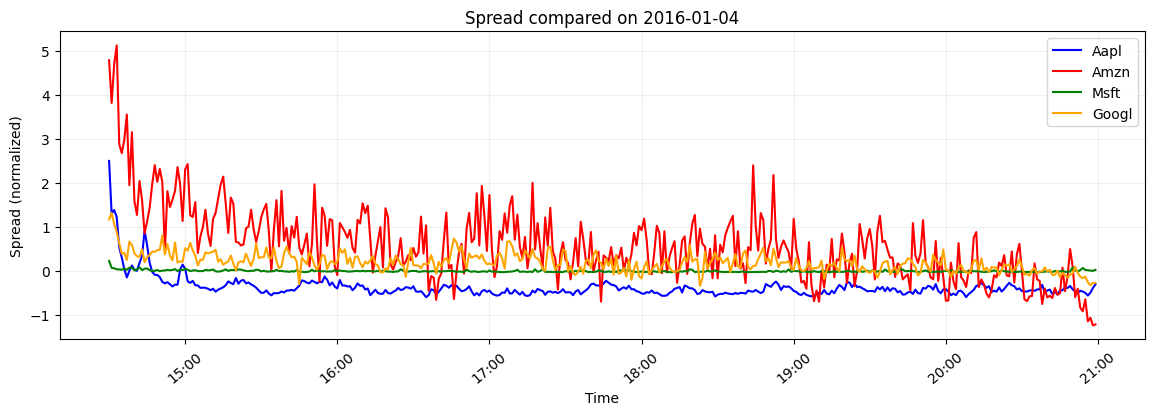

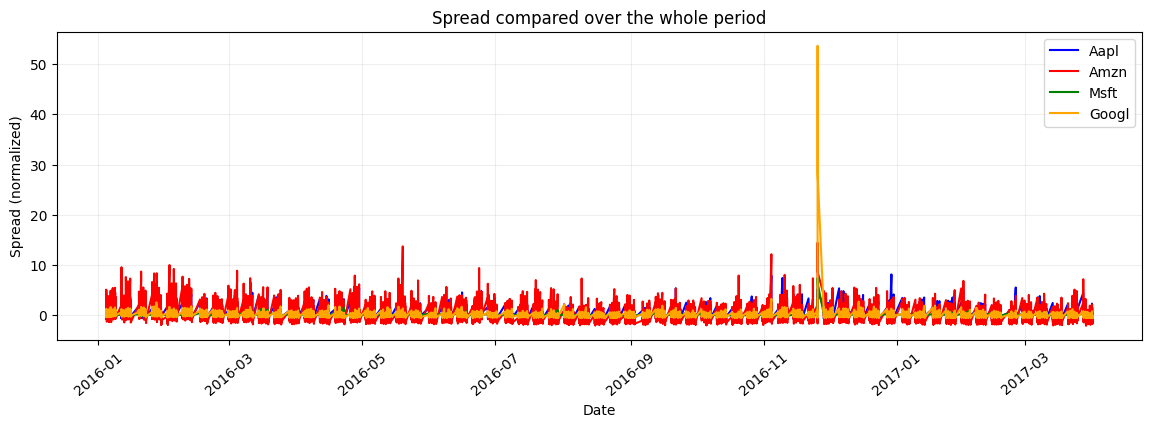

In [105]:
first_day = df_merged_min_BBO_normalized["datetime"][0].date()
plot_metric_day(df_merged_min_BBO_normalized, "spread", first_day)
plot_metric(df_merged_min_BBO_normalized, "spread")